## Getting started
In order to get started, create a virtual environment via conda:

```conda create --file environment.yml```

Then select the newly created virtual environemnt for the notebook's kernel

In [362]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Preprocessing
This preprocessing step aims to:
- Load raw data as a dataframe
- Plot time series features
- Trim first and last 10 seconds of each recording
- Synchronize dataframe into uniform 100 samples per second grid
- Stores preprocessed files in data/processed

**Load raw data**

In [363]:
# TODO Implement load_data function here, returns dataframe
import pandas as pd
import matplotlib.pyplot as plt
def load_data(filepath: str) -> pd.DataFrame:
    return pd.read_csv(filepath)

filepath = 'data/raw/bumpy/2026-09-12_14-09-10/Accelerometer.csv' # insert filepath here
df = load_data(filepath) # load as dataframe

print(df.columns)
df.head()

Index(['time', 'seconds_elapsed', 'z', 'y', 'x'], dtype='str')


,time,seconds_elapsed,z,y,x
0,1789222150095785000,0.054785,12.642402,2.111705,-1.935764
1,1789222150105779000,0.064779,1.998088,2.568794,-1.115979
2,1789222150115774000,0.074774,-13.362187,-4.826614,0.764603
3,1789222150125768000,0.084768,-3.974676,-0.177178,0.352524
4,1789222150135762000,0.094762,4.010883,1.920324,-0.098737


**Plotting function**

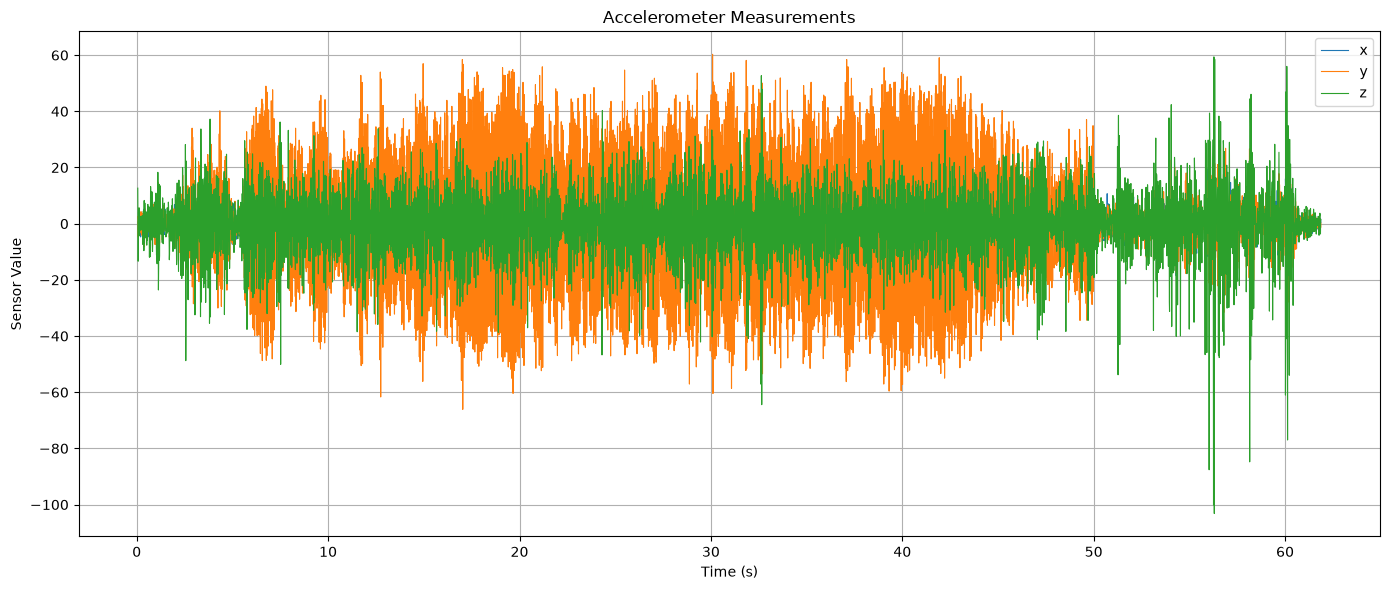

In [364]:
# TODO Implement plotting function here
def plot_features(df: pd.DataFrame):

    plt.figure(figsize=(14,6))

    for axis in ['x', 'y', 'z']:
        plt.plot(df['seconds_elapsed'], df[axis], label=axis, linewidth=0.8)

    plt.xlabel('Time (s)')
    plt.ylabel('Sensor Value')
    plt.title('Accelerometer Measurements')

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()
plot_features(df)

Index(['time', 'seconds_elapsed', 'z', 'y', 'x'], dtype='str')


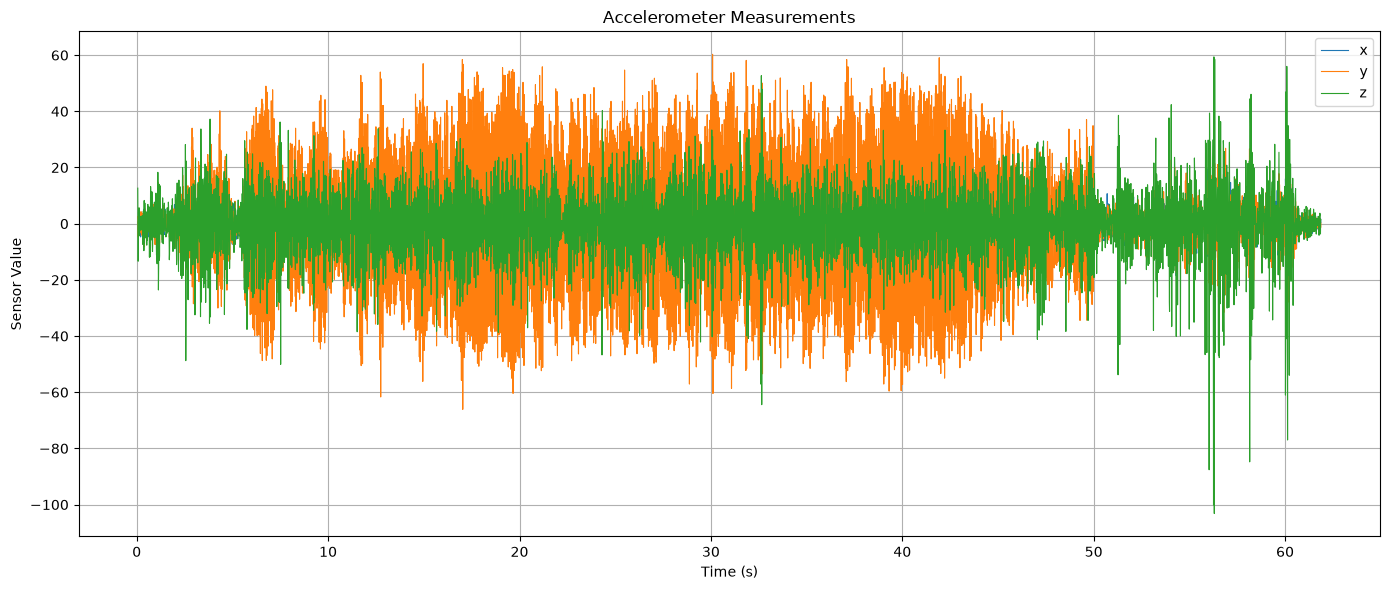

In [365]:
filepath = 'data/raw/bumpy/2026-09-12_14-09-10/Accelerometer.csv'

df = load_data(filepath)

print(df.columns)

plot_features(df)

**Trimming function**

In [366]:
def trim_data(df: pd.DataFrame, limit=10):
    """
    Trim the first and last `limit` seconds of a dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Raw sensor dataframe containing a 'seconds_elapsed' column.
    limit : int or float, default=10
        Number of seconds to remove from the beginning and end.

    Returns
    -------
    pd.DataFrame
        Trimmed dataframe.
    """
    if limit < 0:
        raise ValueError("limit must be non-negative")

    if df.empty:
        return df.copy()

    start_time = df["seconds_elapsed"].iloc[0] + limit
    end_time = df["seconds_elapsed"].iloc[-1] - limit

    return df[
        (df["seconds_elapsed"] >= start_time)
        & (df["seconds_elapsed"] <= end_time)
    ].copy()

**Synchronization**

In [367]:
SAMPLING_FREQUENCY = 100
def synchronize_data(df: pd.DataFrame, fs=SAMPLING_FREQUENCY) -> pd.DataFrame:
    """
    Performs interpolation between data points such that the data seconds_elapsed are uniform.

    :param df: dataframe to synchronize
    :param fs: sampling frequency, sets the number of points per second
    :return: synced dataframe with uniform grid
    """
    # Set index and drop time column
    df = df.drop(columns='time', errors='ignore').set_index("seconds_elapsed")

    # Decrement seconds_elapsed by the minimum
    df.index = df.index - df.index.min()
    
    # Prepare grid
    n = int(np.floor(df.index.max() * fs)) + 1 # Number of points
    grid_index = pd.Index(np.arange(n) / fs, name='seconds_elapsed')


    # Create a temporary union for the index to include the grid index
    combined_index = df.index.union(grid_index)

    # Perform interpolation
    df_sync = (
        df.reindex(combined_index)
        .interpolate(method='index')
        .reindex(grid_index)
    )
    return df_sync

**Proprocess a single file**

In [368]:
def preprocess(filepath: str) -> pd.DataFrame:
    """
    Runs the full preprocessing pipeline given a filepath
    
    :param filepath: path to measurement file
    """
    df = load_data(filepath)
    df = trim_data(df)
    df = synchronize_data(df)

    return df

**Running the preprocessing pipeline on the whole raw data directory**

In [369]:
import os
import shutil

TARGET_FILES = ["Accelerometer.csv", "Gyroscope.csv", "Gravity.csv", "Metadata.csv"]

def preprocess_files(src_root: str, out_root: str):
    """
    Runs the preprocessing pipeline on a given source directory

    :param src_root: Source directory of raw data files
    :param out_root: Target directory of processed files
    """

    for dirpath, dirnames, filenames in os.walk(src_root):
            
        # List all files in this path
        for file in filenames:

          
            # Skip non target files
            if file not in TARGET_FILES:
                continue

            fpath = os.path.join(dirpath, file)

            # Mirror the raw folder structure under data/processed
            outpath = os.path.join(out_root, os.path.relpath(fpath, src_root))
            os.makedirs(os.path.dirname(outpath), exist_ok=True)
            
            # Copy Metadata file
            if file == 'Metadata.csv':
                shutil.copy(fpath, outpath)
                continue

            df_processed = preprocess(fpath)
            df_processed.to_csv(outpath)

src_root = os.path.join('data', 'raw')
out_root = os.path.join('data', 'processed')
preprocess_files(src_root, out_root)
